In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')
df.head(5)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [3]:
df.shape

(44785, 41)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  str    
 1   continent                        44257 non-null  str    
 2   location                         44785 non-null  str    
 3   date                             44785 non-null  str    
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed_per_millio

In [5]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
count,4.418200e+04,43982.000000,43200.000000,44182.000000,43982.000000,43200.000000,43918.000000,43918.000000,43135.000000,43918.000000,...,39442.000000,26322.000000,39967.000000,41366.000000,31358.000000,30963.000000,18658.000000,36139.000000,43963.000000,38558.000000
mean,9.372153e+04,1388.770224,1372.258368,3885.163189,43.323360,43.329499,1778.176471,23.573850,23.160618,55.320410,...,20979.943732,12.029018,251.347231,8.048869,10.834007,32.637049,52.576272,3.115428,74.052595,0.725580
std,9.707004e+05,12665.458657,12420.794948,36227.966483,366.554434,356.193423,3814.416468,72.289186,55.613758,140.662359,...,20466.166309,19.158253,117.620708,4.143192,10.481952,13.408593,31.579386,2.530433,7.364382,0.152673
min,0.000000e+00,-8261.000000,-552.000000,0.000000,-1918.000000,-232.143000,0.000000,-2212.545000,-269.978000,0.000000,...,661.240000,0.100000,79.370000,0.990000,0.100000,7.700000,1.188000,0.100000,53.280000,0.354000
25%,5.300000e+01,0.000000,0.571000,0.000000,0.000000,0.000000,25.373750,0.000000,0.123000,0.000000,...,5338.454000,0.500000,155.898000,5.310000,1.900000,21.400000,21.222000,1.300000,69.910000,0.606000
50%,9.370000e+02,9.000000,14.143000,17.000000,0.000000,0.143000,266.509000,1.475500,2.838000,4.566000,...,14103.452000,1.800000,238.339000,7.110000,6.400000,31.400000,55.182000,2.500000,75.490000,0.755000
75%,9.989000e+03,156.000000,160.857000,213.000000,3.000000,3.000000,1793.012500,16.551500,18.200500,33.616750,...,32415.132000,16.000000,318.949000,10.180000,19.600000,40.900000,83.741000,4.200000,79.930000,0.853000
max,3.054045e+07,313658.000000,288630.000000,952724.000000,10491.000000,7456.714000,42663.811000,4944.376000,882.924000,1237.551000,...,116935.600000,77.600000,724.417000,23.360000,44.000000,78.100000,98.999000,13.800000,86.750000,0.953000


DATA PREPROCESSING

In [6]:
print(df.isnull().sum()) # Count of missing values in each column


iso_code                             264
continent                            528
location                               0
date                                   0
total_cases                          603
new_cases                            803
new_cases_smoothed                  1585
total_deaths                         603
new_deaths                           803
new_deaths_smoothed                 1585
total_cases_per_million              867
new_cases_per_million                867
new_cases_smoothed_per_million      1650
total_deaths_per_million             867
new_deaths_per_million               867
new_deaths_smoothed_per_million     1650
new_tests                          29138
total_tests                        28763
total_tests_per_thousand           28763
new_tests_per_thousand             29138
new_tests_smoothed                 27217
new_tests_smoothed_per_thousand    27217
tests_per_case                     28636
positive_rate                      28252
tests_units     

In [7]:
print(df.isnull().sum()/len(df)*100)# Percentage of missing values in each column

iso_code                            0.589483
continent                           1.178966
location                            0.000000
date                                0.000000
total_cases                         1.346433
new_cases                           1.793011
new_cases_smoothed                  3.539131
total_deaths                        1.346433
new_deaths                          1.793011
new_deaths_smoothed                 3.539131
total_cases_per_million             1.935916
new_cases_per_million               1.935916
new_cases_smoothed_per_million      3.684269
total_deaths_per_million            1.935916
new_deaths_per_million              1.935916
new_deaths_smoothed_per_million     3.684269
new_tests                          65.061963
total_tests                        64.224629
total_tests_per_thousand           64.224629
new_tests_per_thousand             65.061963
new_tests_smoothed                 60.772580
new_tests_smoothed_per_thousand    60.772580
tests_per_

In [8]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'tests_per_case', 'positive_rate', 'tests_units', 'stringency_index',
       'population', 'population_density', 'median_age', 'aged_65_older',
       'aged_70_older', 'gdp_per_capita', 'extreme_poverty',
       'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers',
       'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand',
       'life_expectancy', 'human_development_index'],
      dtype='str')

In [9]:
columns_needed=[
    "location",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths",
    "population"
]
df = df[columns_needed]


In [10]:
#convert date column to datetime format
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   location      44785 non-null  str           
 1   date          44785 non-null  datetime64[us]
 2   total_cases   44182 non-null  float64       
 3   new_cases     43982 non-null  float64       
 4   total_deaths  44182 non-null  float64       
 5   new_deaths    43982 non-null  float64       
 6   population    44521 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 2.4 MB


In [11]:
# Handling missing numeric values by filling with 0
numeric_columns=['total_cases', 'new_cases', 'total_deaths', 'new_deaths']
df[numeric_columns] = df[numeric_columns].fillna(0)
# Handling missing categorical values by filling with 'Unknown'
df['location'] = df['location'].fillna('Unknown')


TREND ANALYSIS  OF NEPAL

In [12]:
#choosing and making  a copy of data for a specific country
country = "Nepal"
df_country =df[df['location']==country].copy()
df_country.head(5)

,location,date,total_cases,new_cases,total_deaths,new_deaths,population
28392,Nepal,2019-12-31,0.0,0.0,0.0,0.0,29136808.0
28393,Nepal,2020-01-01,0.0,0.0,0.0,0.0,29136808.0
28394,Nepal,2020-01-02,0.0,0.0,0.0,0.0,29136808.0
28395,Nepal,2020-01-03,0.0,0.0,0.0,0.0,29136808.0
28396,Nepal,2020-01-04,0.0,0.0,0.0,0.0,29136808.0


C:\Users\DIPESH\AppData\Local\Temp\ipykernel_2900\1052751166.py:4: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=10) # Limit the number of x-axis ticks


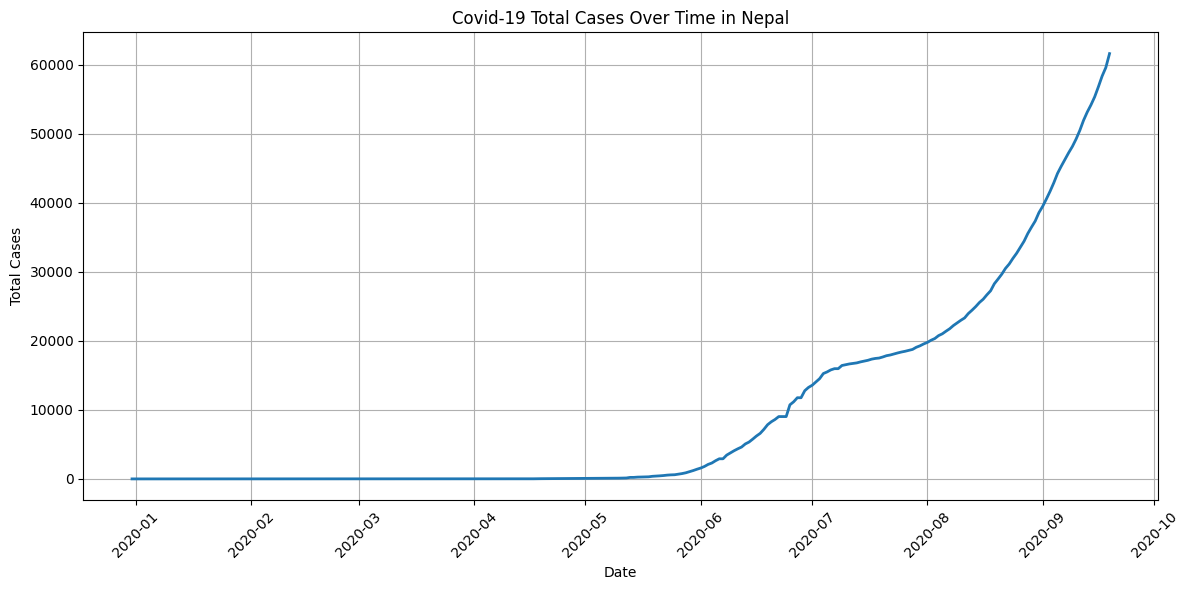

In [13]:
#plotting the total cases over time
plt.figure(figsize=(12,6))
plt.plot(df_country['date'], df_country['total_cases'],linewidth=2)
plt.locator_params(axis='x', nbins=10) # Limit the number of x-axis ticks
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.title(f'Covid-19 Total Cases Over Time in {country}')
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
plt.tight_layout()# Adjust layout to prevent clipping of labels
plt.grid()
plt.show()


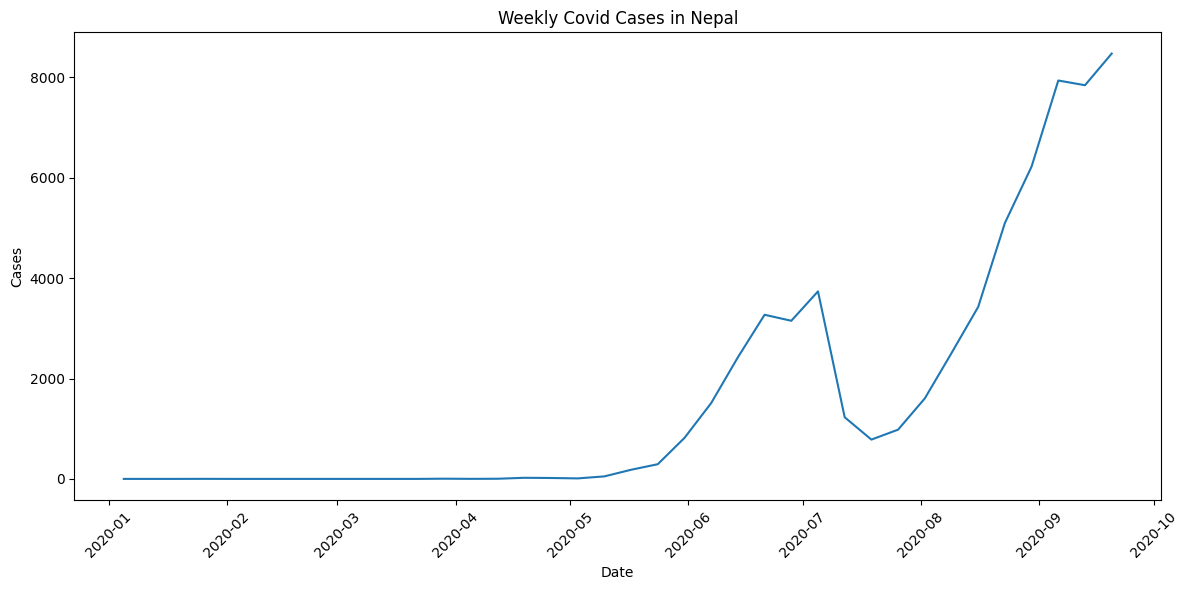

In [14]:
# Reload dataset
df = pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Set index
df = df.set_index("date")

# Filter Nepal
nepal_df = df[df["location"] == "Nepal"]
weekly_cases = nepal_df["new_cases"].resample("W").sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(weekly_cases)

plt.title("Weekly Covid Cases in Nepal")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



COVID 19 WAVE COMPARISIONS BETWEEN NEPAL, INDIA AND CHINA

In [17]:
countries = ['Nepal', 'India', 'China']
from scipy.signal import find_peaks
data=pd.read_csv('C:/PROJECTS/Covid19-analysis/Data/owid-covid-data.csv')
data['date'] = pd.to_datetime(data['date'])
#function to  prepare data for a country
def prepare_country_data(country, height_threshold=50): # Adjust this threshold based on the scale of cases in the country
    country_data=data[data['location'] == country][['date', 'new_cases']].copy()# Select only date and new_cases columns
    country_data['new_cases'] = country_data['new_cases'].fillna(0)# Fill missing values with 0
    country_data['rolling_avg'] = country_data['new_cases'].rolling(window=7).mean()# Calculate 7-day rolling average to smooth the data

    #find peaks
    cases=rolling_avg = country_data['rolling_avg'].to_numpy() # Convert to numpy array for find_peaks
    peaks, _ = find_peaks(cases, height=height_threshold) # Find peaks
    peak_dates = country_data['date'].iloc[peaks] # Get corresponding dates for peaks
    peak_values = country_data['rolling_avg'].iloc[peaks] # Get corresponding new_cases values for peaks
    
    return country_data, peak_dates, peak_values



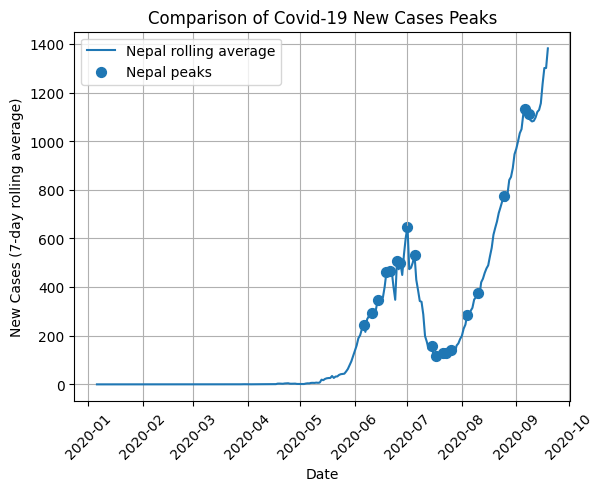

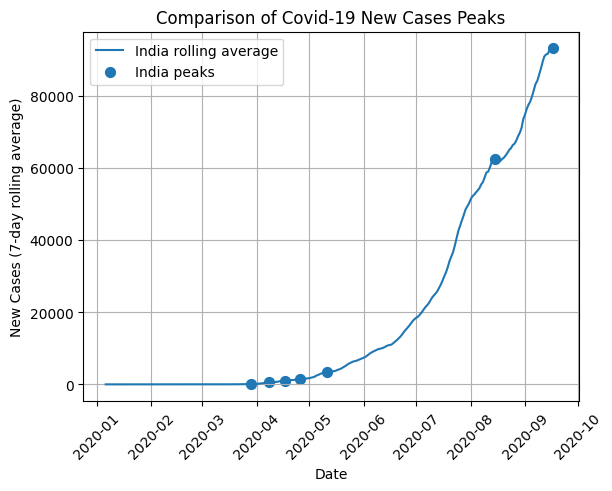

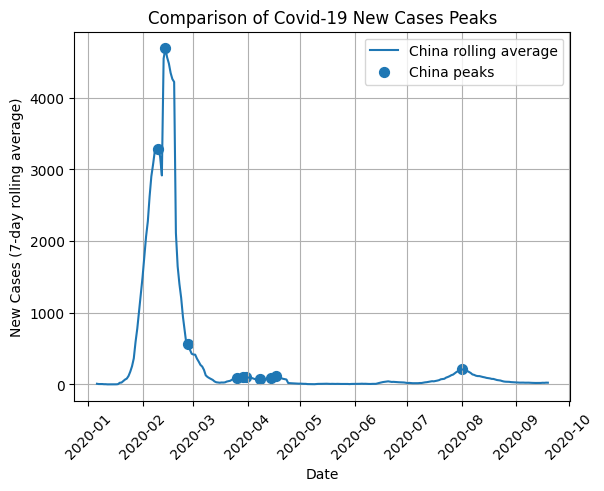

In [ ]:
#plot comparisions
plt.Figure(figsize=(12,6))
for country in countries:
    country_data, peak_dates, peak_values = prepare_country_data(country, height_threshold=50)# Adjust this threshold based on the scale of cases in the country

    #plotting the rolling average of new cases
    plt.plot(country_data['date'], country_data['rolling_avg'], label=f'{country} rolling average')# Plot rolling average of new cases
    
    #plotting peaks
    plt.scatter(peak_dates, peak_values,marker='o',s=50, label=f'{country} peaks')# Plot peaks of new cases
    plt.title('Comparison of Covid-19 New Cases Peaks')
    plt.xlabel('Date')
    plt.ylabel('New Cases (7-day rolling average)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.show()

In [23]:
# COMPARE PEAKS IN TABLES
peak_summary = []

for country in countries:
    _, peak_dates, peak_values = prepare_country_data(country, height_threshold=4)
    for date, value in zip(peak_dates, peak_values):
        peak_summary.append({'Country': country, 'Date': date.date(), 'Peak Cases': int(value)})

peak_df = pd.DataFrame(peak_summary)
print(peak_df.sort_values(['Country', 'Date']))


   Country        Date  Peak Cases
32   China  2020-02-10        3285
33   China  2020-02-14        4687
34   China  2020-02-27         563
35   China  2020-03-17          26
36   China  2020-03-26          86
..     ...         ...         ...
20   Nepal  2020-08-04         285
21   Nepal  2020-08-10         377
22   Nepal  2020-08-25         776
23   Nepal  2020-09-06        1133
24   Nepal  2020-09-08        1110

[64 rows x 3 columns]
